In [36]:
L_values = [16, 32, 64, 128]
Tc = 2.269
nu = 1.0

print(f"Required Temperature ranges for scaled temperature in [-2, 3] (with Tc={Tc}, nu={nu}):")
for L in L_values:
    # Scaled temperature X = (T - Tc) * L**(1/nu)
    # So if we want X to be between -2 and 3:
    # -2 = (T_min - Tc) * L**(1/nu) => T_min = Tc - 2 / L**(1/nu)
    #  3 = (T_max - Tc) * L**(1/nu) => T_max = Tc + 3 / L**(1/nu)
    
    T_min = Tc - 2.0 / (L**(1/nu))
    T_max = Tc + 3.0 / (L**(1/nu))
    
    print(f"L={L:<3} -> T range: [{T_min:.4f}, {T_max:.4f}]")

Required Temperature ranges for scaled temperature in [-2, 3] (with Tc=2.269, nu=1.0):
L=16  -> T range: [2.1440, 2.4565]
L=32  -> T range: [2.2065, 2.3628]
L=64  -> T range: [2.2378, 2.3159]
L=128 -> T range: [2.2534, 2.2924]


# Finite Size Scaling — Modelo de Ising 2D

Análisis de escalado de tamaño finito (FSS) para el modelo de Ising 2D simulado con tres algoritmos: **Metropolis**, **Glauber** y **Wolff**.

Se determinan:
- La temperatura crítica $T_c$ mediante el cruce del cumulante de Binder $U_4$.
- Los exponentes críticos $\nu$, $\beta/\nu$ y $\gamma/\nu$ mediante ajustes log-log.
- El colapso de datos como verificación del escalado.

## 1. Importaciones y carga de datos

Leemos los ficheros de simulación. Cada uno tiene columnas: `L, T, e, m, Cv, m2, m4`.
A partir de ellas calculamos el cumulante de Binder $U_4 = 1 - \frac{\langle m^4\rangle}{3\langle m^2\rangle^2}$ y la susceptibilidad $\chi = L^2(\langle m^2\rangle - \langle |m|\rangle^2)$.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq, curve_fit

# Parametros para que todas las graficas salgan iguales
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
})

# Ficheros de datos, sus nombres
archivos = {
    'Metropolis': 'metropolis_2d.txt',
    'Glauber':    'glauber_2d.txt',
    'Wolff':      'wolff_2d.txt',
}

columnas = ['L', 'T', 'e', 'm', 'Cv', 'm2', 'm4']

# Leer y añadir columnas derivadas
data = {}
for algo, fichero in archivos.items():
    df = pd.read_csv(fichero, sep=r'\s+', header=None, names=columnas)
    df['U4']  = 1.0 - df['m4'] / (3.0 * df['m2']**2)
    df['chi'] = df['L']**2 * (df['m2'] - df['m']**2)
    data[algo] = df

L_values = sorted(data['Wolff']['L'].unique())
print('Tamaños de red:', L_values)

Tamaños de red: [np.int64(16), np.int64(32), np.int64(64), np.int64(128)]


## 2. Funciones auxiliares

- **`find_Tc`**: Calcula dos estimadores de $T_c$ con cruces de $U_4(T)$ entre pares consecutivos de $L$:
  - **Media de cruces por pares** ($T_c^{pair}$).
  - **Intercepto en tamaño infinito** ajustando $T_{cross}$ vs $1/L^2$ ($T_c^{\infty}$).
- **`get_exponents`**: Calcula los exponentes críticos a partir de ajustes lineales en escala log-log:
  - $1/\nu$: pendiente de $\ln|dU_4/dT|$ vs $\ln L$
  - $\beta/\nu$: pendiente (cambiada de signo) de $\ln\langle|m|\rangle(T_c)$ vs $\ln L$
  - $\gamma/\nu$: pendiente de $\ln\chi_{\max}$ vs $\ln L$

In [38]:
def linfit(x, a, b):
    """Recta y = a*x + b para ajustar en escala log-log."""
    return a * x + b


def find_Tc(df, L_values, t_window=(1.8, 2.8), tc_ref=2.2691853):
    """
    Calcula dos estimadores de Tc con cruces de Binder entre pares consecutivos:
    1) media de cruces por pares (Tc_pair_mean)
    2) extrapolación lineal T_cross vs 1/L^2 (Tc_inf_intercept)
    """
    interps = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interps[L] = interp1d(
            s['T'].values,
            s['U4'].values,
            kind='linear',
            bounds_error=False,
            fill_value='extrapolate'
        )

    pair_crossings = []
    x_invL2 = []

    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        s1 = df[df['L'] == L1]
        s2 = df[df['L'] == L2]
        T_min = max(s1['T'].min(), s2['T'].min(), t_window[0])
        T_max = min(s1['T'].max(), s2['T'].max(), t_window[1])

        Ts = np.linspace(T_min, T_max, 2000)
        diff = interps[L1](Ts) - interps[L2](Ts)

        roots = []
        for j in range(len(diff) - 1):
            if diff[j] == 0:
                roots.append(Ts[j])
            elif diff[j] * diff[j + 1] < 0:
                root = brentq(
                    lambda t: interps[L1](t) - interps[L2](t),
                    Ts[j], Ts[j + 1]
                )
                roots.append(root)

        if len(roots) == 0:
            continue

        tc_pair = roots[np.argmin(np.abs(np.array(roots) - tc_ref))]
        pair_crossings.append(tc_pair)
        x_invL2.append(1.0 / (L2 ** 2))

    pair_crossings = np.array(pair_crossings, dtype=float)
    x_invL2 = np.array(x_invL2, dtype=float)

    # Método 1: media de cruces por pares
    if len(pair_crossings) > 0:
        tc_pair_mean = float(np.mean(pair_crossings))
        tc_pair_err = float(np.std(pair_crossings)) if len(pair_crossings) > 1 else 0.0
    else:
        tc_pair_mean, tc_pair_err = np.nan, np.nan

    # Método 2: intercepto L->infinito en ajuste lineal vs 1/L^2
    if len(pair_crossings) >= 2:
        p = np.polyfit(x_invL2, pair_crossings, deg=1)
        slope, tc_inf = p[0], p[1]
        residuals = pair_crossings - (slope * x_invL2 + tc_inf)
        tc_inf_err = float(np.std(residuals)) if len(residuals) > 1 else 0.0
    elif len(pair_crossings) == 1:
        tc_inf = float(pair_crossings[0])
        tc_inf_err = 0.0
    else:
        tc_inf, tc_inf_err = np.nan, np.nan

    return {
        'Tc_pair_mean': tc_pair_mean,
        'Tc_pair_err': tc_pair_err,
        'Tc_inf_intercept': tc_inf,
        'Tc_inf_err': tc_inf_err,
        'pair_crossings': pair_crossings,
        'x_invL2': x_invL2,
    }


def get_exponents(df, L_values, Tc):
    """Calcula nu, beta/nu y gamma/nu mediante ajustes log-log."""
    interp_U4 = {}
    interp_m = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interp_U4[L] = interp1d(s['T'].values, s['U4'].values, kind='cubic')
        interp_m[L]  = interp1d(s['T'].values, s['m'].values,  kind='cubic')

    dT = 0.001

    # 1/nu: derivada de U4 en Tc
    log_L, log_dU = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if Tc - dT >= s['T'].min() and Tc + dT <= s['T'].max():
            deriv = abs((interp_U4[L](Tc + dT) - interp_U4[L](Tc - dT)) / (2 * dT))
            log_L.append(np.log(L))
            log_dU.append(np.log(deriv))
    (inv_nu, _), _ = curve_fit(linfit, log_L, log_dU)
    nu = 1.0 / inv_nu

    # beta/nu: magnetización en Tc
    log_L, log_m = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if s['T'].min() <= Tc <= s['T'].max():
            log_L.append(np.log(L))
            log_m.append(np.log(interp_m[L](Tc)))
    (slope_m, _), _ = curve_fit(linfit, log_L, log_m)
    beta_over_nu = -slope_m

    # gamma/nu: máximo de chi
    log_L, log_chi = [], []
    for L in L_values:
        s = df[df['L'] == L]
        log_L.append(np.log(L))
        log_chi.append(np.log(s['chi'].max()))
    (gamma_over_nu, _), _ = curve_fit(linfit, log_L, log_chi)

    return nu, beta_over_nu, gamma_over_nu

## 5. Cumulante de Binder $U_4$

Un panel por algoritmo mostrando $U_4(T)$ para cada $L$, con la línea vertical en $T_c$. El cruce de las curvas para distintos $L$ señala la temperatura crítica.

Tc por interpolación polinómica de cruces (U4):


,Tc_poly_mean,Tc_poly_mean_err,Tc_poly_extrap,Tc_poly_extrap_err
algoritmo,,,,
Metropolis,2.266226,0.001025,2.265189,0.000358
Glauber,2.266379,0.000388,2.265962,0.000042
Wolff,2.272435,0.005017,2.267018,0.000138


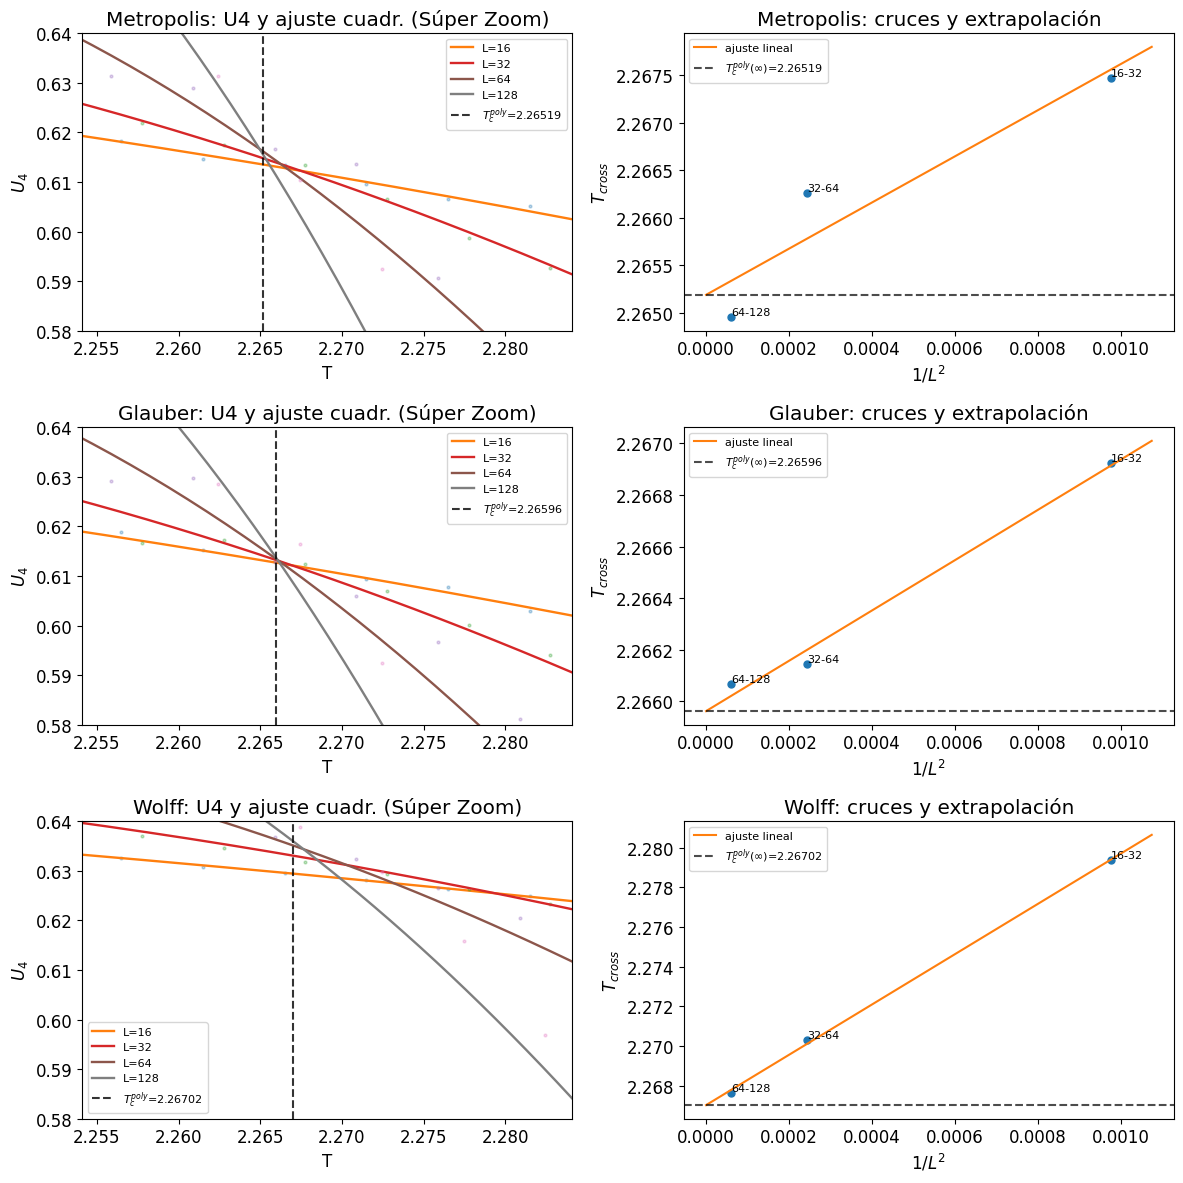

In [39]:
# 6. Interpolación polinómica (cuadrática) del cumulante de Binder
#    y extrapolación de Tc con cruces entre tamaños consecutivos

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _fit_quadratic_near_tc(df_algo, L, tc_guess, window=0.12, min_pts=5):
    s = df_algo[df_algo['L'] == L].sort_values('T')[['T', 'U4']].copy()
    sw = s[(s['T'] >= tc_guess - window) & (s['T'] <= tc_guess + window)]

    if len(sw) < min_pts:
        s = s.assign(dist=np.abs(s['T'] - tc_guess)).sort_values('dist')
        sw = s.head(min_pts).sort_values('T')[['T', 'U4']]

    if len(sw) < 3:
        return None, None

    coeff = np.polyfit(sw['T'].values, sw['U4'].values, deg=2)
    poly = np.poly1d(coeff)
    return poly, sw


def _select_crossing_root(poly_diff, tc_guess, tmin, tmax):
    roots = np.roots(poly_diff)
    real_roots = np.real(roots[np.isreal(roots)])
    real_roots = real_roots[(real_roots >= tmin) & (real_roots <= tmax)]
    if len(real_roots) == 0:
        return np.nan
    return real_roots[np.argmin((real_roots - tc_guess) ** 2)]


poly_cross_summary = []
TARGET_T = 2.2691

for algo, df in data.items():
    tc_guess = float(results.loc[algo, 'Tc']) if 'results' in globals() else float(df['T'].median())

    # Ajuste cuadrático U4(T) para cada tamaño L, cerca de Tc
    fitted = {}
    fitted_windows = {}
    for L in L_values:
        poly, sw = _fit_quadratic_near_tc(df, L, tc_guess=tc_guess, window=0.12, min_pts=5)
        fitted[L] = poly
        fitted_windows[L] = sw

    # Cruces entre pares consecutivos de tamaños
    crossings = []
    x_invL2 = []
    pair_labels = []

    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        if fitted[L1] is None or fitted[L2] is None:
            crossings.append(np.nan)
            x_invL2.append(1.0 / (L2 ** 2))
            pair_labels.append(f'{L1}-{L2}')
            continue

        s1 = df[df['L'] == L1]
        s2 = df[df['L'] == L2]
        tmin = max(s1['T'].min(), s2['T'].min())
        tmax = min(s1['T'].max(), s2['T'].max())

        poly_diff = np.poly1d(fitted[L2]) - np.poly1d(fitted[L1])
        tc_cross = _select_crossing_root(poly_diff, tc_guess=tc_guess, tmin=tmin, tmax=tmax)

        crossings.append(tc_cross)
        x_invL2.append(1.0 / (L2 ** 2))
        pair_labels.append(f'{L1}-{L2}')

    crossings = np.array(crossings, dtype=float)
    x_invL2 = np.array(x_invL2, dtype=float)
    valid = np.isfinite(crossings)
    
    # Calculamos la media aritmética de los cruces y su desviación
    tc_mean = np.mean(crossings[valid]) if valid.sum() > 0 else np.nan
    tc_mean_err = np.std(crossings[valid]) if valid.sum() > 1 else 0.0

    if valid.sum() >= 2:
        # Tc(inf) = intercepto del ajuste lineal crossing vs 1/L^2
        p = np.polyfit(x_invL2[valid], crossings[valid], deg=1)
        slope, tc_inf = p[0], p[1]
        residuals = crossings[valid] - (slope * x_invL2[valid] + tc_inf)
        tc_inf_err = float(np.std(residuals)) if len(residuals) > 1 else 0.0
    elif valid.sum() == 1:
        slope, tc_inf = np.nan, crossings[valid][0]
        tc_inf_err = 0.0
        warnings.warn(f'{algo}: solo hay un cruce válido; no se puede extrapolar linealmente.')
    else:
        slope, tc_inf = np.nan, np.nan
        tc_inf_err = np.nan
        warnings.warn(f'{algo}: no se encontraron cruces válidos.')

    poly_cross_summary.append({
        'algoritmo': algo,
        'Tc_poly_mean': tc_mean,
        'Tc_poly_mean_err': tc_mean_err,
        'Tc_poly_extrap': tc_inf,
        'Tc_poly_extrap_err': tc_inf_err,
        'slope_vs_1_over_L2': slope,
        'pairs': pair_labels,
        'crossings': crossings,
        'x_invL2': x_invL2,
        'fitted': fitted,
        'windows': fitted_windows,
    })

# Tabla resumen
poly_results = pd.DataFrame([
    {
        'algoritmo': d['algoritmo'],
        'Tc_poly_mean': d['Tc_poly_mean'],
        'Tc_poly_mean_err': d['Tc_poly_mean_err'],
        'Tc_poly_extrap': d['Tc_poly_extrap'],
        'Tc_poly_extrap_err': d['Tc_poly_extrap_err'],
    }
    for d in poly_cross_summary
]).set_index('algoritmo')

print('Tc por interpolación polinómica de cruces (U4):')
display(poly_results)

# Gráficas: (1) ajustes cuadráticos cerca de Tc, (2) extrapolación de cruces
fig, axes = plt.subplots(len(poly_cross_summary), 2, figsize=(12, 4 * len(poly_cross_summary)))
if len(poly_cross_summary) == 1:
    axes = np.array([axes])

for row, d in enumerate(poly_cross_summary):
    algo = d['algoritmo']
    ax1, ax2 = axes[row, 0], axes[row, 1]

    # Panel izquierdo: U4(T) + ajuste cuadrático por L
    for L in L_values:
        s = data[algo][data[algo]['L'] == L].sort_values('T')
        ax1.plot(s['T'], s['U4'], 'o', ms=2, alpha=0.3)

        poly = d['fitted'][L]
        sw = d['windows'][L]
        if poly is not None and sw is not None and len(sw) >= 3:
            tgrid = np.linspace(sw['T'].min(), sw['T'].max(), 200)
            ax1.plot(tgrid, poly(tgrid), lw=1.7, label=f'L={L}')

    if np.isfinite(d['Tc_poly_extrap']):
        ax1.axvline(d['Tc_poly_extrap'], color='k', ls='--', alpha=0.8,
                    label=f"$T_c^{{poly}}$={d['Tc_poly_extrap']:.5f}")

    # ZOOM APLICADO
    ax1.set_xlim(TARGET_T - 0.015, TARGET_T + 0.015)
    ax1.set_ylim(0.58, 0.64)

    ax1.set_title(f'{algo}: U4 y ajuste cuadr. (Súper Zoom)')
    ax1.set_xlabel('T')
    ax1.set_ylabel(r'$U_4$')
    ax1.legend(fontsize=8)

    # Panel derecho: cruces vs 1/L^2
    x = d['x_invL2']
    y = d['crossings']
    valid = np.isfinite(y)

    ax2.plot(x[valid], y[valid], 'o', ms=5)
    for xv, yv, lbl in zip(x[valid], y[valid], np.array(d['pairs'])[valid]):
        ax2.text(xv, yv, lbl, fontsize=8, ha='left', va='bottom')

    if valid.sum() >= 2 and np.isfinite(d['slope_vs_1_over_L2']) and np.isfinite(d['Tc_poly_extrap']):
        xx = np.linspace(0, max(x) * 1.1, 200)
        yy = d['Tc_poly_extrap'] + d['slope_vs_1_over_L2'] * xx
        ax2.plot(xx, yy, '-', lw=1.5, label='ajuste lineal')
        ax2.axhline(d['Tc_poly_extrap'], color='k', ls='--', alpha=0.7,
                    label=f"$T_c^{{poly}}(\infty)$={d['Tc_poly_extrap']:.5f}")

    ax2.set_title(f'{algo}: cruces y extrapolación')
    ax2.set_xlabel(r'$1/L^2$')
    ax2.set_ylabel(r'$T_{cross}$')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

Tc por interpolación lineal de cruces (U4):


,Tc_lin_mean,Tc_lin_mean_err,Tc_lin_extrap,Tc_lin_extrap_err
algoritmo,,,,
Metropolis,2.269217,0.002570,2.268516,0.002487
Glauber,2.267917,0.001838,2.267174,0.001704
Wolff,2.274776,0.003145,2.271438,0.000584


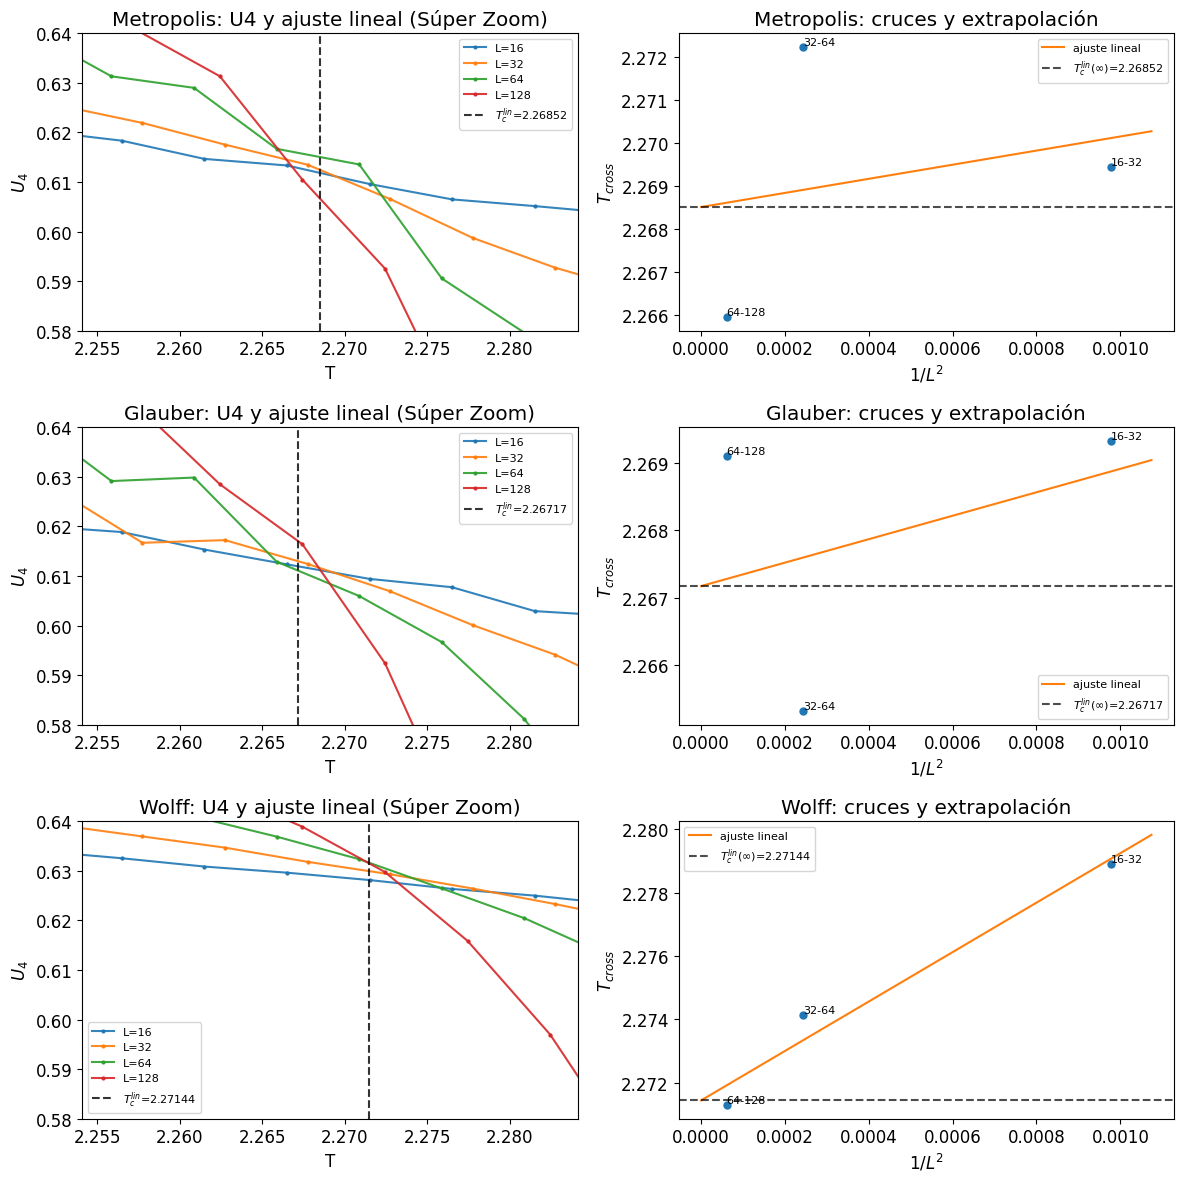

In [40]:
# 7. Interpolación lineal estricta del cumulante de Binder
#    y extrapolación de Tc con cruces entre tamaños consecutivos

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq

def _fit_linear_near_tc(df_algo, L, tc_guess, window=0.15):
    s = df_algo[df_algo['L'] == L].sort_values('T')[['T', 'U4']].drop_duplicates(subset=['T']).copy()
    sw = s[(s['T'] >= tc_guess - window) & (s['T'] <= tc_guess + window)]

    if len(sw) < 2:
        return None, None

    interp = interp1d(sw['T'].values, sw['U4'].values, kind='linear', bounds_error=False, fill_value=np.nan)
    return interp, sw

def _select_crossing_root_lin(interp1, interp2, tc_guess, tmin, tmax):
    ts = np.linspace(tmin, tmax, 2000)
    diff = interp1(ts) - interp2(ts)
    
    roots = []
    for j in range(len(diff) - 1):
        if not np.isnan(diff[j]) and not np.isnan(diff[j+1]) and diff[j] * diff[j + 1] <= 0:
            try:
                root = brentq(lambda t: interp1(t) - interp2(t), ts[j], ts[j + 1])
                roots.append(root)
            except ValueError:
                pass
                
    if len(roots) == 0:
        return np.nan
    roots = np.array(roots)
    return roots[np.argmin(np.abs(roots - tc_guess))]

linear_cross_summary = []
TARGET_T = 2.2691

for algo, df in data.items():
    tc_guess = float(results.loc[algo, 'Tc']) if 'results' in globals() else float(df['T'].median())

    fitted = {}
    fitted_windows = {}
    for L in L_values:
        interp, sw = _fit_linear_near_tc(df, L, tc_guess=tc_guess, window=0.12)
        fitted[L] = interp
        fitted_windows[L] = sw

    crossings = []
    x_invL2 = []
    pair_labels = []

    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        if fitted[L1] is None or fitted[L2] is None:
            crossings.append(np.nan)
            x_invL2.append(1.0 / (L2 ** 2))
            pair_labels.append(f'{L1}-{L2}')
            continue

        s1 = fitted_windows[L1]
        s2 = fitted_windows[L2]
        tmin = max(s1['T'].min(), s2['T'].min())
        tmax = min(s1['T'].max(), s2['T'].max())

        tc_cross = _select_crossing_root_lin(fitted[L1], fitted[L2], tc_guess=tc_guess, tmin=tmin, tmax=tmax)

        crossings.append(tc_cross)
        x_invL2.append(1.0 / (L2 ** 2))
        pair_labels.append(f'{L1}-{L2}')

    crossings = np.array(crossings, dtype=float)
    x_invL2 = np.array(x_invL2, dtype=float)
    valid = np.isfinite(crossings)

    # Calculamos la media aritmética de los cruces y su desviación
    tc_mean = np.mean(crossings[valid]) if valid.sum() > 0 else np.nan
    tc_mean_err = np.std(crossings[valid]) if valid.sum() > 1 else 0.0

    if valid.sum() >= 2:
        p = np.polyfit(x_invL2[valid], crossings[valid], deg=1)
        slope, tc_inf = p[0], p[1]
        residuals = crossings[valid] - (slope * x_invL2[valid] + tc_inf)
        tc_inf_err = float(np.std(residuals)) if len(residuals) > 1 else 0.0
    elif valid.sum() == 1:
        slope, tc_inf = np.nan, crossings[valid][0]
        tc_inf_err = 0.0
    else:
        slope, tc_inf = np.nan, np.nan
        tc_inf_err = np.nan

    linear_cross_summary.append({
        'algoritmo': algo,
        'Tc_lin_mean': tc_mean,
        'Tc_lin_mean_err': tc_mean_err,
        'Tc_lin_extrap': tc_inf,
        'Tc_lin_extrap_err': tc_inf_err,
        'slope_vs_1_over_L2': slope,
        'pairs': pair_labels,
        'crossings': crossings,
        'x_invL2': x_invL2,
        'fitted': fitted,
        'windows': fitted_windows,
    })

# Tabla resumen
lin_results = pd.DataFrame([
    {
        'algoritmo': d['algoritmo'],
        'Tc_lin_mean': d['Tc_lin_mean'],
        'Tc_lin_mean_err': d['Tc_lin_mean_err'],
        'Tc_lin_extrap': d['Tc_lin_extrap'],
        'Tc_lin_extrap_err': d['Tc_lin_extrap_err'],
    }
    for d in linear_cross_summary
]).set_index('algoritmo')

print('Tc por interpolación lineal de cruces (U4):')
display(lin_results)

# Gráficas
fig, axes = plt.subplots(len(linear_cross_summary), 2, figsize=(12, 4 * len(linear_cross_summary)))
if len(linear_cross_summary) == 1:
    axes = np.array([axes])

for row, d in enumerate(linear_cross_summary):
    algo = d['algoritmo']
    ax1, ax2 = axes[row, 0], axes[row, 1]

    # Panel izquierdo: Interpolación lineal entre puntos
    for L in L_values:
        s = data[algo][data[algo]['L'] == L].sort_values('T')
        ax1.plot(s['T'], s['U4'], 'o', ms=2, alpha=0.3)

        interp = d['fitted'][L]
        sw = d['windows'][L]
        if interp is not None and sw is not None and len(sw) >= 2:
            color = ax1.lines[-1].get_color()
            ax1.plot(sw['T'], sw['U4'], '.-', ms=4, alpha=0.9, color=color, label=f'L={L}')

    if np.isfinite(d['Tc_lin_extrap']):
        ax1.axvline(d['Tc_lin_extrap'], color='k', ls='--', alpha=0.8,
                    label=f"$T_c^{{lin}}$={d['Tc_lin_extrap']:.5f}")

    ax1.set_xlim(TARGET_T - 0.015, TARGET_T + 0.015)
    ax1.set_ylim(0.58, 0.64)

    ax1.set_title(f'{algo}: U4 y ajuste lineal (Súper Zoom)')
    ax1.set_xlabel('T')
    ax1.set_ylabel(r'$U_4$')
    ax1.legend(fontsize=8)

    # Panel derecho: cruces
    x = d['x_invL2']
    y = d['crossings']
    valid = np.isfinite(y)

    ax2.plot(x[valid], y[valid], 'o', ms=5)
    for xv, yv, lbl in zip(x[valid], y[valid], np.array(d['pairs'])[valid]):
        ax2.text(xv, yv, lbl, fontsize=8, ha='left', va='bottom')

    if valid.sum() >= 2 and np.isfinite(d['slope_vs_1_over_L2']) and np.isfinite(d['Tc_lin_extrap']):
        xx = np.linspace(0, max(x) * 1.1, 200)
        yy = d['Tc_lin_extrap'] + d['slope_vs_1_over_L2'] * xx
        ax2.plot(xx, yy, '-', lw=1.5, label='ajuste lineal')
        ax2.axhline(d['Tc_lin_extrap'], color='k', ls='--', alpha=0.7,
                    label=f"$T_c^{{lin}}(\infty)$={d['Tc_lin_extrap']:.5f}")

    ax2.set_title(f'{algo}: cruces y extrapolación')
    ax2.set_xlabel(r'$1/L^2$')
    ax2.set_ylabel(r'$T_{cross}$')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

def plot_fss_collapse_chi_metropolis(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Metropolis\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Metropolis'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-2, 3)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Metropolis
widgets.interact(
    plot_fss_collapse_chi_metropolis,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …

In [42]:
def plot_fss_collapse_chi_glauber(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Glauber\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Glauber'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-2, 3)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Glauber
widgets.interact(
    plot_fss_collapse_chi_glauber,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …

In [ ]:
def plot_fss_collapse_chi_wolff(Tc, nu, gamma):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"FSS Collapse | Susceptibility | Wolff\n$T_c$ = {Tc:.4f}, $\\nu$ = {nu:.3f}, $\\gamma$ = {gamma:.3f}", fontsize=12)
    algo = 'Wolff'
    
    df = data[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        T_vals = s['T'].values
        
        x = (T_vals - Tc) * (L**(1.0 / nu))
        y = s['chi'].values * (L**(-gamma / nu))
            
        # Plot only points
        ax.plot(x, y, 'o', markersize=5, alpha=0.7, label=f'L={L}')
        
    ax.set_xlabel(r'$(T - T_c) L^{1/\nu}$')
    ax.set_ylabel(r'$\chi L^{-\gamma/\nu}$')
    ax.set_xlim(-2, 3)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive sliders for Wolff
widgets.interact(
    plot_fss_collapse_chi_wolff,
    Tc=widgets.FloatSlider(value=2.269, min=2.24, max=2.30, step=0.001, description='$T_c$:', readout_format='.4f'),
    nu=widgets.FloatSlider(value=1.000, min=0.8, max=1.2, step=0.005, description='$\\nu$:', readout_format='.3f'),
    gamma=widgets.FloatSlider(value=1.750, min=1.5, max=2.0, step=0.005, description='$\\gamma$:', readout_format='.3f')
);

interactive(children=(FloatSlider(value=2.269, description='$T_c$:', max=2.3, min=2.24, readout_format='.4f', …